## Atividade 3 - Macroeconomia Avançada 1

### Aluno: José Kawan dos Santos Santana

In [1]:
import ipeadatapy as ip
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [13]:
# pip install python-bcb

In [2]:
import bcb
from bcb import sgs

#### Parte da documentação

[Python BCB documentação](https://wilsonfreitas.github.io/python-bcb/api.html)

In [3]:
ibc = bcb.sgs.get({'IBCbr': 24363}, start='2003-01-01'),            # IBC-Br mensal (índice)
comm = bcb.sgs.get({'commodities': 27574}, start='2003-01-01'),     # Índice de preços de commodities - Brasil (índice)
ipca = bcb.sgs.get({'IPCA': 433}, start='2003-01-01'),              # Variação percentual mensal do IPCA (variação % mensal)
selic = bcb.sgs.get({'Selic': 4390}, start='2003-01-01'),           # Taxa de juros - Selic acumulada no mês - (variação % mensal)
cambio = bcb.sgs.get({'Cambio': 3696}, start='2003-01-01'),         # Taxa de câmbio - Livre - Dólar americano (venda) - Fim de período - mensal (nível)

print(cambio)     

(            Cambio
Date              
2003-01-01  3.5258
2003-02-01  3.5632
2003-03-01  3.3531
2003-04-01  2.8898
2003-05-01  2.9656
...            ...
2024-11-01  6.0535
2024-12-01  6.1923
2025-01-01  5.8301
2025-02-01  5.8488
2025-03-01  5.7422

[267 rows x 1 columns],)


Eu coloquei o início das variáveis para janeiro de 2003 porque os dados do IBC-Br estão disponíveis a partir dessa data.

In [7]:
ibc = ibc[0]                     # pegando só a coluna de dados
comm = comm[0]
ipca = ipca[0]
selic = selic[0]
cambio = cambio[0]

# Transformar em DataFrames
ibc = pd.DataFrame(ibc)
comm = pd.DataFrame(comm)
ipca = pd.DataFrame(ipca)
selic = pd.DataFrame(selic)
cambio = pd.DataFrame(cambio)

# Ajustar índices para período mensal (caso o índice seja datetime)
ibc.index = pd.to_datetime(ibc.index).to_period('M')
comm.index = pd.to_datetime(comm.index).to_period('M')
ipca.index = pd.to_datetime(ipca.index).to_period('M')
selic.index = pd.to_datetime(selic.index).to_period('M')
cambio.index = pd.to_datetime(cambio.index).to_period('M')

In [9]:
display(cambio)

,Cambio
Date,
2003-01,3.5258
2003-02,3.5632
2003-03,3.3531
2003-04,2.8898
2003-05,2.9656
...,...
2024-11,6.0535
2024-12,6.1923
2025-01,5.8301


In [11]:
# Unir os três DataFrames pelo índice (join com interseção de datas)
df = pd.concat([ibc, comm, ipca, selic, cambio], axis=1).dropna()

# Visualizar o resultado
print(df.head())

            IBCbr  commodities  IPCA  Selic  Cambio
Date                                               
2003-01  67.44572       101.45  2.25   1.97  3.5258
2003-02  69.20861       109.05  1.57   1.83  3.5632
2003-03  72.53661       100.18  1.23   1.78  3.3531
2003-04  71.67673        90.84  0.97   1.87  2.8898
2003-05  70.35122        87.33  0.61   1.97  2.9656


Calcule uma medida de taxa de juros real utilizando o IPCA como deflator.

In [13]:
# criando uma medida de juros real com o IPCA como deflator

df['juros_real'] = df['Selic'] - df['IPCA']

print(df[['Selic', 'IPCA', 'juros_real']].head())

         Selic  IPCA  juros_real
Date                            
2003-01   1.97  2.25       -0.28
2003-02   1.83  1.57        0.26
2003-03   1.78  1.23        0.55
2003-04   1.87  0.97        0.90
2003-05   1.97  0.61        1.36


In [15]:
df2 = df[['IBCbr', 'commodities', 'IPCA', 'juros_real', 'Cambio']]

print(df2)

             IBCbr  commodities  IPCA  juros_real  Cambio
Date                                                     
2003-01   67.44572       101.45  2.25       -0.28  3.5258
2003-02   69.20861       109.05  1.57        0.26  3.5632
2003-03   72.53661       100.18  1.23        0.55  3.3531
2003-04   71.67673        90.84  0.97        0.90  2.8898
2003-05   70.35122        87.33  0.61        1.36  2.9656
...            ...          ...   ...         ...     ...
2024-10  109.49845       430.22  0.56        0.37  5.7779
2024-11  105.76017       447.00  0.39        0.40  6.0535
2024-12  104.44111       477.11  0.52        0.41  6.1923
2025-01  103.05176       482.57  0.16        0.85  5.8301
2025-02  106.61259       461.10  1.31       -0.32  5.8488

[266 rows x 5 columns]


#### A. Plote das séries

In [17]:
df.index = df.index.to_timestamp()

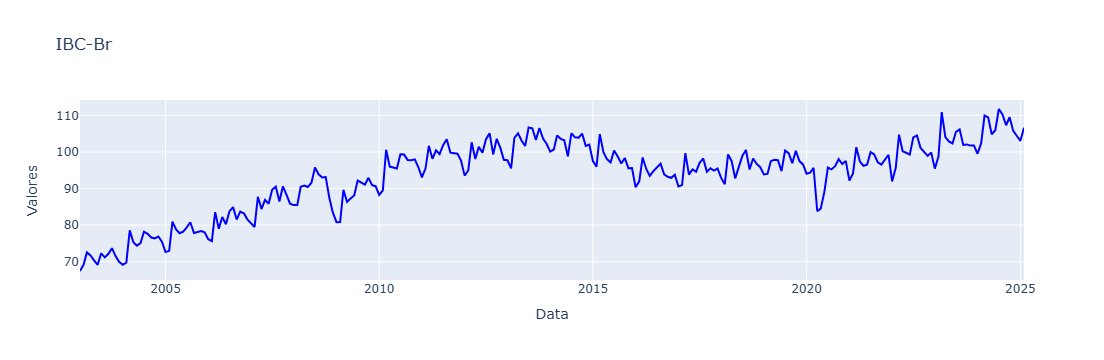

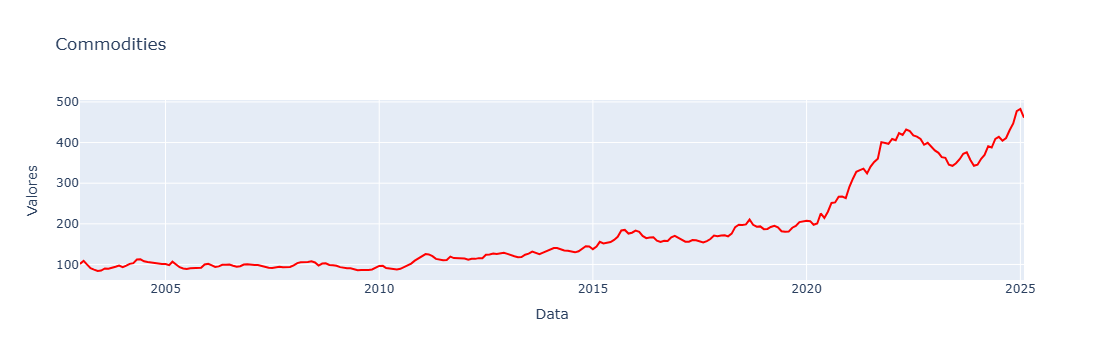

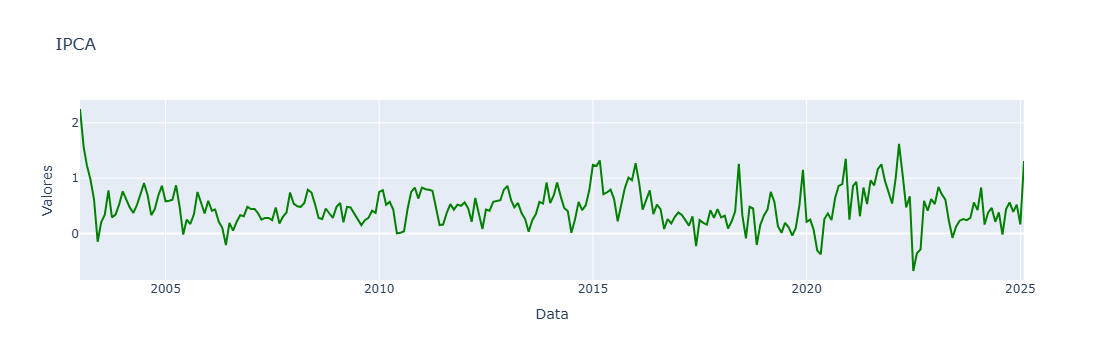

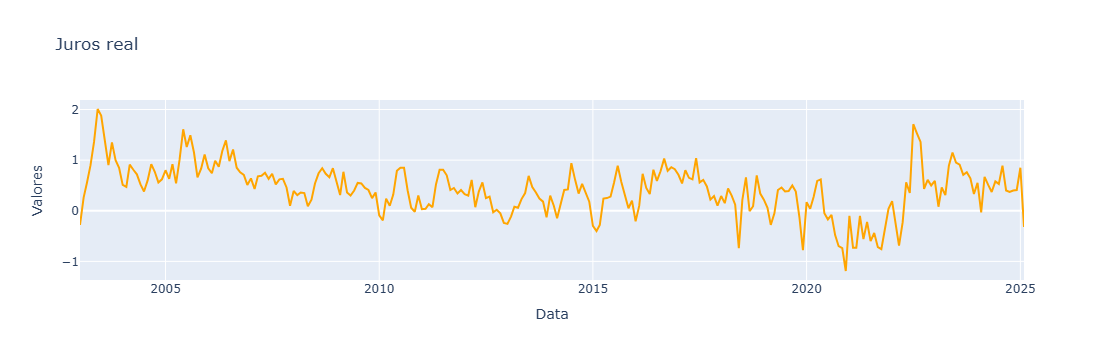

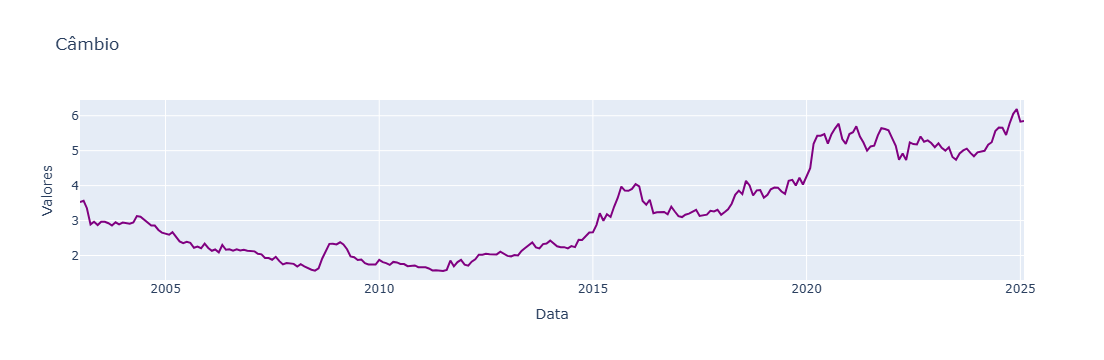

In [19]:
import plotly.graph_objects as go

# df.index = df.index.to_timestamp()

# Função para criar o gráfico de cada variável
def create_plot(x, y, title, yaxis_title, color):
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=x, y=y, mode='lines', name=title, line=dict(color=color)))
    fig.update_layout(
        title=title,
        xaxis_title='Data',
        yaxis_title=yaxis_title,
        hovermode='x unified'
    )
    fig.show()

# Criando os gráficos individuais
create_plot(df.index, df['IBCbr'], 'IBC-Br', 'Valores', 'blue')
create_plot(df.index, df['commodities'], 'Commodities', 'Valores', 'red')
create_plot(df.index, df['IPCA'], 'IPCA', 'Valores', 'green')
create_plot(df.index, df['juros_real'], 'Juros real', 'Valores', 'orange')
create_plot(df.index, df['Cambio'], 'Câmbio', 'Valores', 'purple')

In [21]:
##### Verificando estacionaridade das 5 séries

from statsmodels.tsa.stattools import adfuller

# Verificar estacionariedade (opcional)
for col in df2.columns:
    result = adfuller(df2[col].dropna())
    print(f"{col}: p-value = {result[1]:.4f}")

IBCbr: p-value = 0.3590
commodities: p-value = 0.9941
IPCA: p-value = 0.0000
juros_real: p-value = 0.0000
Cambio: p-value = 0.9687


- **H₀ (Hipótese Nula)**:
"A série tem uma raiz unitária (não é estacionária)."
Em outras palavras, há uma tendência estocástica (como um passeio aleatório) que torna a série dependente do tempo.
- **H₁ (Hipótese Alternativa)**:
"A série não tem raiz unitária (é estacionária)."
Isso significa que a série flutua em torno de uma média constante, com variância finita e sem tendência temporal

As séries do IPCA e dos juros reais são estacionárias. Vou estacionarizar as 3 outras séries e refazer o teste de estacionaridade.

In [23]:
# Diferenciação de primeira ordem
df2['IBCbr_diff'] = df2['IBCbr'].diff().dropna()
df2['commodities_diff'] = df2['commodities'].diff().dropna()
df2['Cambio_diff'] = df2['Cambio'].diff().dropna()

print(df2)

             IBCbr  commodities  IPCA  juros_real  Cambio  IBCbr_diff  \
Date                                                                    
2003-01   67.44572       101.45  2.25       -0.28  3.5258         NaN   
2003-02   69.20861       109.05  1.57        0.26  3.5632     1.76289   
2003-03   72.53661       100.18  1.23        0.55  3.3531     3.32800   
2003-04   71.67673        90.84  0.97        0.90  2.8898    -0.85988   
2003-05   70.35122        87.33  0.61        1.36  2.9656    -1.32551   
...            ...          ...   ...         ...     ...         ...   
2024-10  109.49845       430.22  0.56        0.37  5.7779     2.18617   
2024-11  105.76017       447.00  0.39        0.40  6.0535    -3.73828   
2024-12  104.44111       477.11  0.52        0.41  6.1923    -1.31906   
2025-01  103.05176       482.57  0.16        0.85  5.8301    -1.38935   
2025-02  106.61259       461.10  1.31       -0.32  5.8488     3.56083   

         commodities_diff  Cambio_diff  
Date     

In [25]:
# Passo 2: Remover linhas com NaN (resultado da diferenciação)
df3 = df2[['IBCbr_diff', 'commodities_diff', 'IPCA', 'juros_real', 'Cambio_diff']].dropna()

# Verificar o resultado
print(df3.head())

         IBCbr_diff  commodities_diff  IPCA  juros_real  Cambio_diff
Date                                                                
2003-02     1.76289              7.60  1.57        0.26       0.0374
2003-03     3.32800             -8.87  1.23        0.55      -0.2101
2003-04    -0.85988             -9.34  0.97        0.90      -0.4633
2003-05    -1.32551             -3.51  0.61        1.36       0.0758
2003-06    -1.20293             -3.37 -0.15        2.01      -0.0936


Os dados vão começar a partir de fevereiro de 2003 porque como eu diferenciei, perdi a primeira observação dessas variáveis diferenciadas.

In [27]:
#### verificar se as séries se tornaram estacionárias

from statsmodels.tsa.stattools import adfuller

for col in df3.columns:
    p_valor = adfuller(df3[col].dropna())[1]
    print(f"{col}: p-valor = {p_valor:.4f}")

IBCbr_diff: p-valor = 0.0010
commodities_diff: p-valor = 0.0026
IPCA: p-valor = 0.0000
juros_real: p-valor = 0.0488
Cambio_diff: p-valor = 0.0000


#### B. Escolha lags por AIC/SBC/HQ

In [29]:
from statsmodels.tsa.api import VAR

# Seleção do número ótimo de lags com base nos critérios de informação
model = VAR(df3)
lag_selection = model.select_order(maxlags=13)

# Exibindo os resultados dos critérios
print(lag_selection.summary())

# Pegando o número de lags sugerido por cada critério
aic_lag = lag_selection.aic
bic_lag = lag_selection.bic
hqic_lag = lag_selection.hqic

print(f"Lag escolhido pelo AIC: {aic_lag}")
print(f"Lag escolhido pelo BIC (SBC): {bic_lag}")
print(f"Lag escolhido pelo Hannan-Quinn: {hqic_lag}")

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -1.965      -1.895      0.1401      -1.937
1       -5.121      -4.701    0.005969      -4.952
2       -5.675     -4.905*    0.003431      -5.365
3       -5.755      -4.634    0.003171      -5.304
4       -5.862      -4.392    0.002851      -5.270
5       -6.030      -4.210    0.002414      -5.298
6       -6.322      -4.151    0.001808     -5.448*
7       -6.296      -3.775    0.001861      -5.282
8       -6.352      -3.481    0.001769      -5.197
9       -6.409      -3.187    0.001682      -5.112
10      -6.574      -3.003    0.001436      -5.137
11      -6.686      -2.765    0.001296      -5.108
12     -6.921*      -2.649   0.001037*      -5.202
13      -6.845      -2.223    0.001134      -4.985
--------------------------------------------------
Lag escolhido pelo AIC: 12
Lag escolhido pelo BIC (SBC): 2
Lag escolhido pelo Hann

#### C. Estime o modelo VAR e realize os testes de diagnóstico/especificação do modelo como indicados em sala de aula.

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tsa.stattools import acf

In [35]:
# Criar o modelo VAR
model = VAR(df3)

# Ajustar o modelo com p lags
results = model.fit(2)
print(results.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Wed, 30, Apr, 2025
Time:                     21:14:57
--------------------------------------------------------------------
No. of Equations:         5.00000    BIC:                   -4.83147
Nobs:                     263.000    HQIC:                  -5.27829
Log likelihood:          -1077.33    FPE:                 0.00377914
AIC:                     -5.57850    Det(Omega_mle):      0.00307906
--------------------------------------------------------------------
Results for equation IBCbr_diff
                         coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------------------
const                       0.446915         0.525002            0.851           0.395
L1.IBCbr_diff               0.005374         0.057075            0.094           0.925
L1.commodities_diff         0.0

##### Autocorrelação dos resíduos (Ljung-Box)

- **H₀ (Hipótese Nula)**:
Os resíduos não são autocorrelacionados (ou seja, seguem um processo de ruído branco).
(Não há padrões de correlação serial nos resíduos.)
- **H₁ (Hipótese Alternativa)**:
Os resíduos são autocorrelacionados (há dependência temporal nos resíduos).uos).

In [37]:
# Obter os resíduos
resid = results.resid

# Teste de Ljung-Box para autocorrelação
from statsmodels.stats.diagnostic import acorr_ljungbox

for col in resid.columns:
    lb_test = acorr_ljungbox(resid[col], lags=[12], return_df=True)
    print(f"Teste Ljung-Box para {col}:")
    print(lb_test)
    print("\n")

Teste Ljung-Box para IBCbr_diff:
       lb_stat     lb_pvalue
12  141.024722  3.719357e-24


Teste Ljung-Box para commodities_diff:
      lb_stat  lb_pvalue
12  39.381567   0.000091


Teste Ljung-Box para IPCA:
      lb_stat  lb_pvalue
12  17.139538   0.144423


Teste Ljung-Box para juros_real:
      lb_stat  lb_pvalue
12  28.552863   0.004588


Teste Ljung-Box para Cambio_diff:
     lb_stat  lb_pvalue
12  8.216891    0.76796




Exemplo dos juros real: Isso significa que falhamos em rejeitar H₀, ou seja, não há evidência de autocorrelação nos resíduos da variável juros_real para as defasagens testadas (até lag 6).

##### Normalidade dos resíduos (D’Agostino-Pearson test)

- **H₀ (Hipótese Nula)**:
Os resíduos seguem uma distribuição normal (média zero, variância constante, simetria e curtose adequadas).
- **H₁ (Hipótese Alternativa)**:
Os resíduos não seguem uma distribuição normal (podem ser assimétricos, ter caudas pesadas ou outliers excessivos).os).

In [39]:
from scipy.stats import normaltest

for col in resid.columns:
    stat, p = normaltest(resid[col])
    print(f"Teste de normalidade para {col}: estatística={stat:.3f}, p-valor={p:.3f}")
    if p > 0.05:
        print("Resíduos parecem normais\n")
    else:
        print("Resíduos não parecem normais\n")

Teste de normalidade para IBCbr_diff: estatística=5.108, p-valor=0.078
Resíduos parecem normais

Teste de normalidade para commodities_diff: estatística=48.015, p-valor=0.000
Resíduos não parecem normais

Teste de normalidade para IPCA: estatística=10.512, p-valor=0.005
Resíduos não parecem normais

Teste de normalidade para juros_real: estatística=4.527, p-valor=0.104
Resíduos parecem normais

Teste de normalidade para Cambio_diff: estatística=17.627, p-valor=0.000
Resíduos não parecem normais



##### Teste de heterocedasticidade dos resíduos

- **H₀ (Hipótese Nula)**:
Não há heterocedasticidade condicional (os resíduos têm variância constante).
- **H₁ (Hipótese Alternativa)**:
Há heterocedasticidade condicional (a variância dos resíduos depende de valores passados).

In [41]:
from statsmodels.stats.diagnostic import het_arch

for col in resid.columns:
    arch_test = het_arch(resid[col])
    print(f"Teste ARCH para {col}:")
    print(f"Estatística LM: {arch_test[0]}, p-valor: {arch_test[1]}")
    if arch_test[1] > 0.05:
        print("Não há evidência de heterocedasticidade\n")
    else:
        print("Há evidência de heterocedasticidade\n")

Teste ARCH para IBCbr_diff:
Estatística LM: 13.648634794354681, p-valor: 0.18963003592683098
Não há evidência de heterocedasticidade

Teste ARCH para commodities_diff:
Estatística LM: 65.34500371382572, p-valor: 3.4816787376322353e-10
Há evidência de heterocedasticidade

Teste ARCH para IPCA:
Estatística LM: 11.517183476368546, p-valor: 0.31866754744392695
Não há evidência de heterocedasticidade

Teste ARCH para juros_real:
Estatística LM: 10.651646266134154, p-valor: 0.38529387914670316
Não há evidência de heterocedasticidade

Teste ARCH para Cambio_diff:
Estatística LM: 28.09048995495112, p-valor: 0.001745990887928727
Há evidência de heterocedasticidade



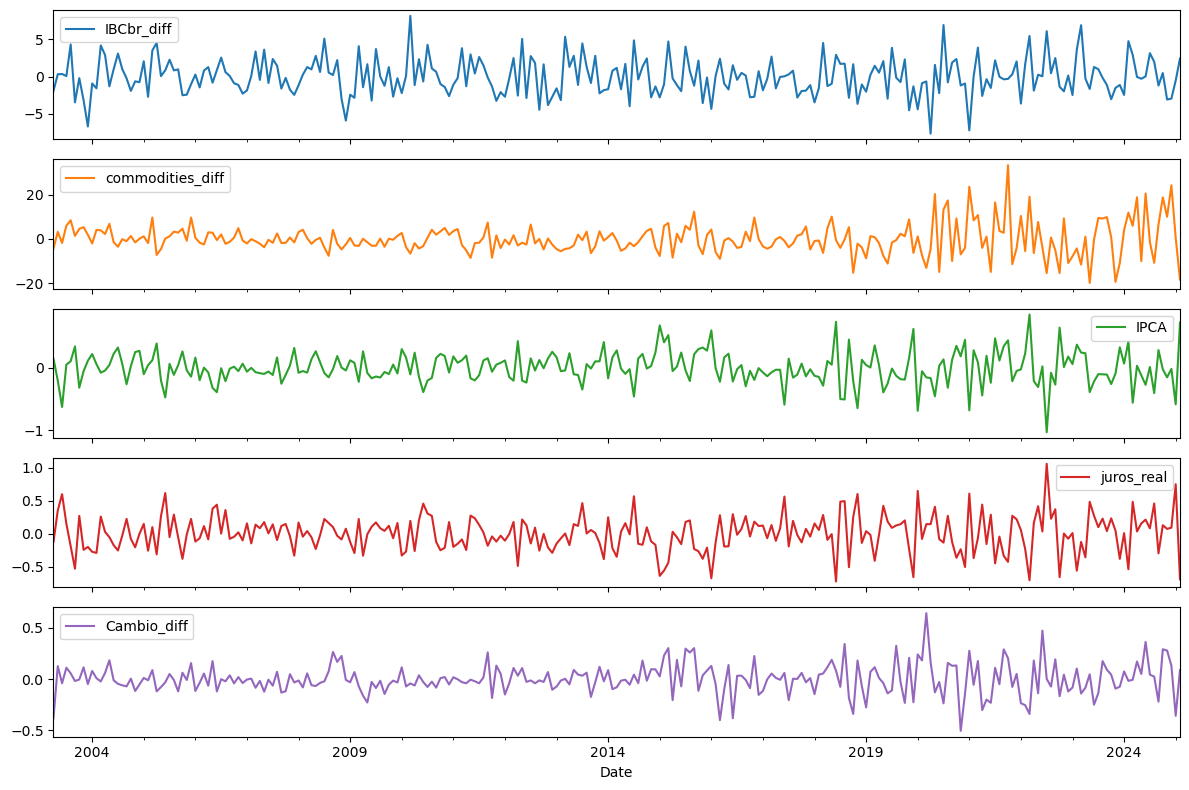

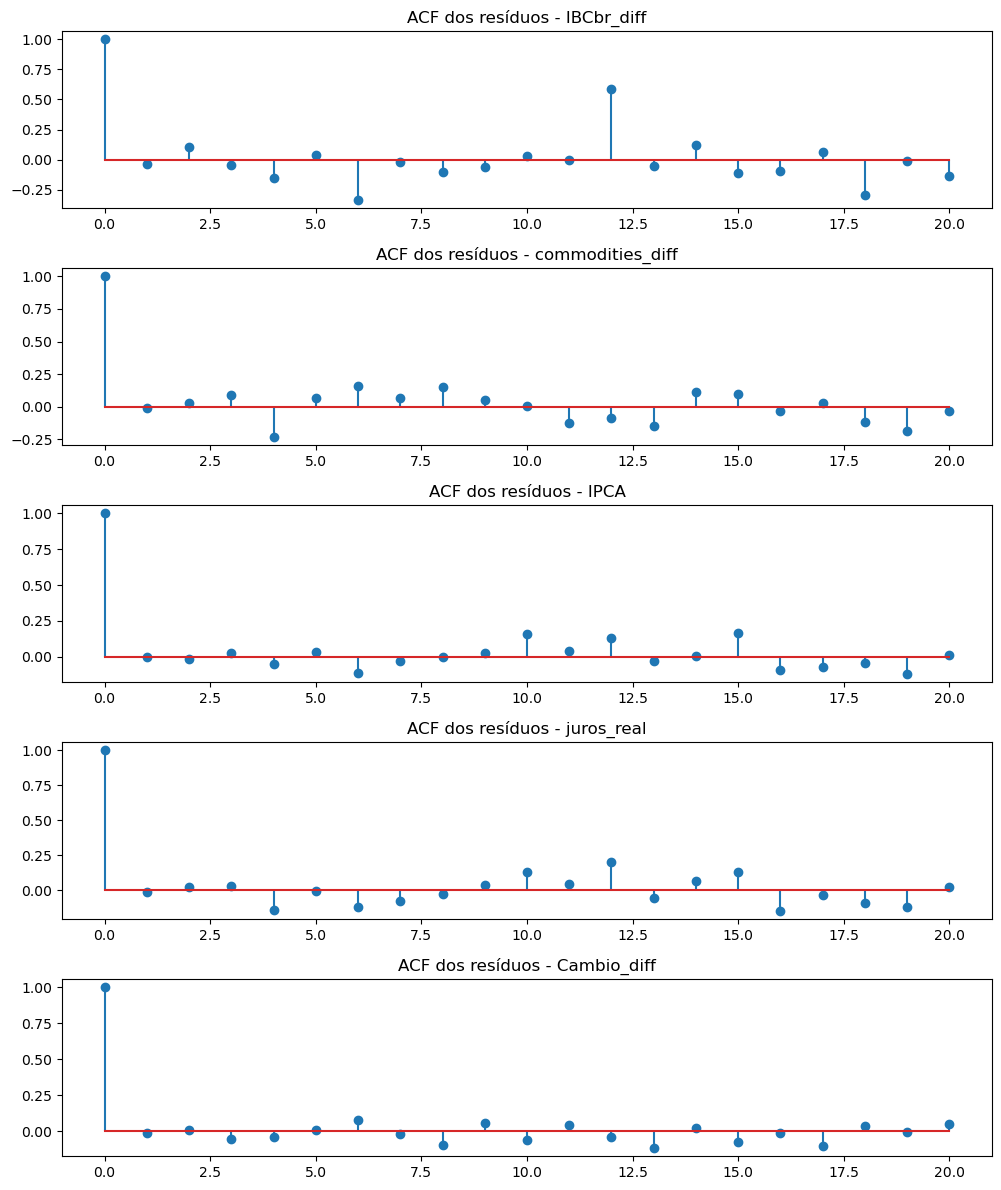

In [43]:
# Plotar resíduos
resid.plot(subplots=True, figsize=(12, 8))
plt.tight_layout()
plt.show()

# Plotar ACF dos resíduos
fig, axes = plt.subplots(nrows=len(resid.columns), ncols=1, figsize=(10, 12))
for i, col in enumerate(resid.columns):
    acf_vals = acf(resid[col], nlags=20)
    axes[i].stem(acf_vals)
    axes[i].set_title(f"ACF dos resíduos - {col}")
plt.tight_layout()
plt.show()

In [45]:
# Verificar as raízes do polinômio característico
roots = results.roots
print("Raízes do polinômio característico:")
print(roots)

# Verificar se o modelo é estável (todas as raízes devem estar fora do círculo unitário)
print("\nMódulo das raízes:")
print(np.abs(roots))
if np.all(np.abs(roots) > 1):
    print("O modelo VAR é estável")
else:
    print("O modelo VAR não é estável")

Raízes do polinômio característico:
[-30.40890571-0.j           3.8480245 -0.j
   1.14800133+2.87398918j   1.14800133-2.87398918j
  -2.49510308-0.j          -2.07484016-0.j
   1.66797338-0.j          -0.13514872+1.58749804j
  -0.13514872-1.58749804j   1.03504661-0.j        ]

Módulo das raízes:
[30.40890571  3.8480245   3.09478931  3.09478931  2.49510308  2.07484016
  1.66797338  1.59324047  1.59324047  1.03504661]
O modelo VAR é estável


#### D. Imponha uma identificação recursiva. 

Se tiver dúvidas na ordenação, consulte Christiano, Eichenbaum and Evans (1999) ou CEE(2005). Justifique a ordenação.

##### Ordenação

1. Preço de commodities (mais exógeno)
2. Câmbio
3. PIB
4. Inflação
5. Taxa de juros (mais endógeno)

In [47]:
df4 = df3[['commodities_diff', 'Cambio_diff', 'IBCbr_diff', 'IPCA', 'juros_real']]

print(df4)

         commodities_diff  Cambio_diff  IBCbr_diff  IPCA  juros_real
Date                                                                
2003-02              7.60       0.0374     1.76289  1.57        0.26
2003-03             -8.87      -0.2101     3.32800  1.23        0.55
2003-04             -9.34      -0.4633    -0.85988  0.97        0.90
2003-05             -3.51       0.0758    -1.32551  0.61        1.36
2003-06             -3.37      -0.0936    -1.20293 -0.15        2.01
...                   ...          ...         ...   ...         ...
2024-10             18.96       0.3298     2.18617  0.56        0.37
2024-11             16.78       0.2756    -3.73828  0.39        0.40
2024-12             30.11       0.1388    -1.31906  0.52        0.41
2025-01              5.46      -0.3622    -1.38935  0.16        0.85
2025-02            -21.47       0.0187     3.56083  1.31       -0.32

[265 rows x 5 columns]


In [56]:
############### SALVANDO ESSE DF COMO EXCEL PARA FAZER A 2° QUESTÃO NO R

##### Vendo meu diretório

# import os

# print(os.getcwd())

C:\Users\KAWAN


In [58]:
####### Salvando na pasta 'python arquivos'

# df4.to_excel("C:/Users/KAWAN/Desktop/python arquivos/df4.xlsx", index=False)

#### IRFs

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from numpy.linalg import cholesky

Matriz de impacto estrutural (Cholesky):
 [[ 7.05642671  0.          0.          0.          0.        ]
 [ 0.04391538  0.14065337  0.          0.          0.        ]
 [-0.12023373 -0.19324903  2.4942796   0.          0.        ]
 [ 0.01967089 -0.01909515 -0.00738854  0.25810684  0.        ]
 [-0.02147225  0.01511542  0.04045493 -0.26187183  0.07879123]]


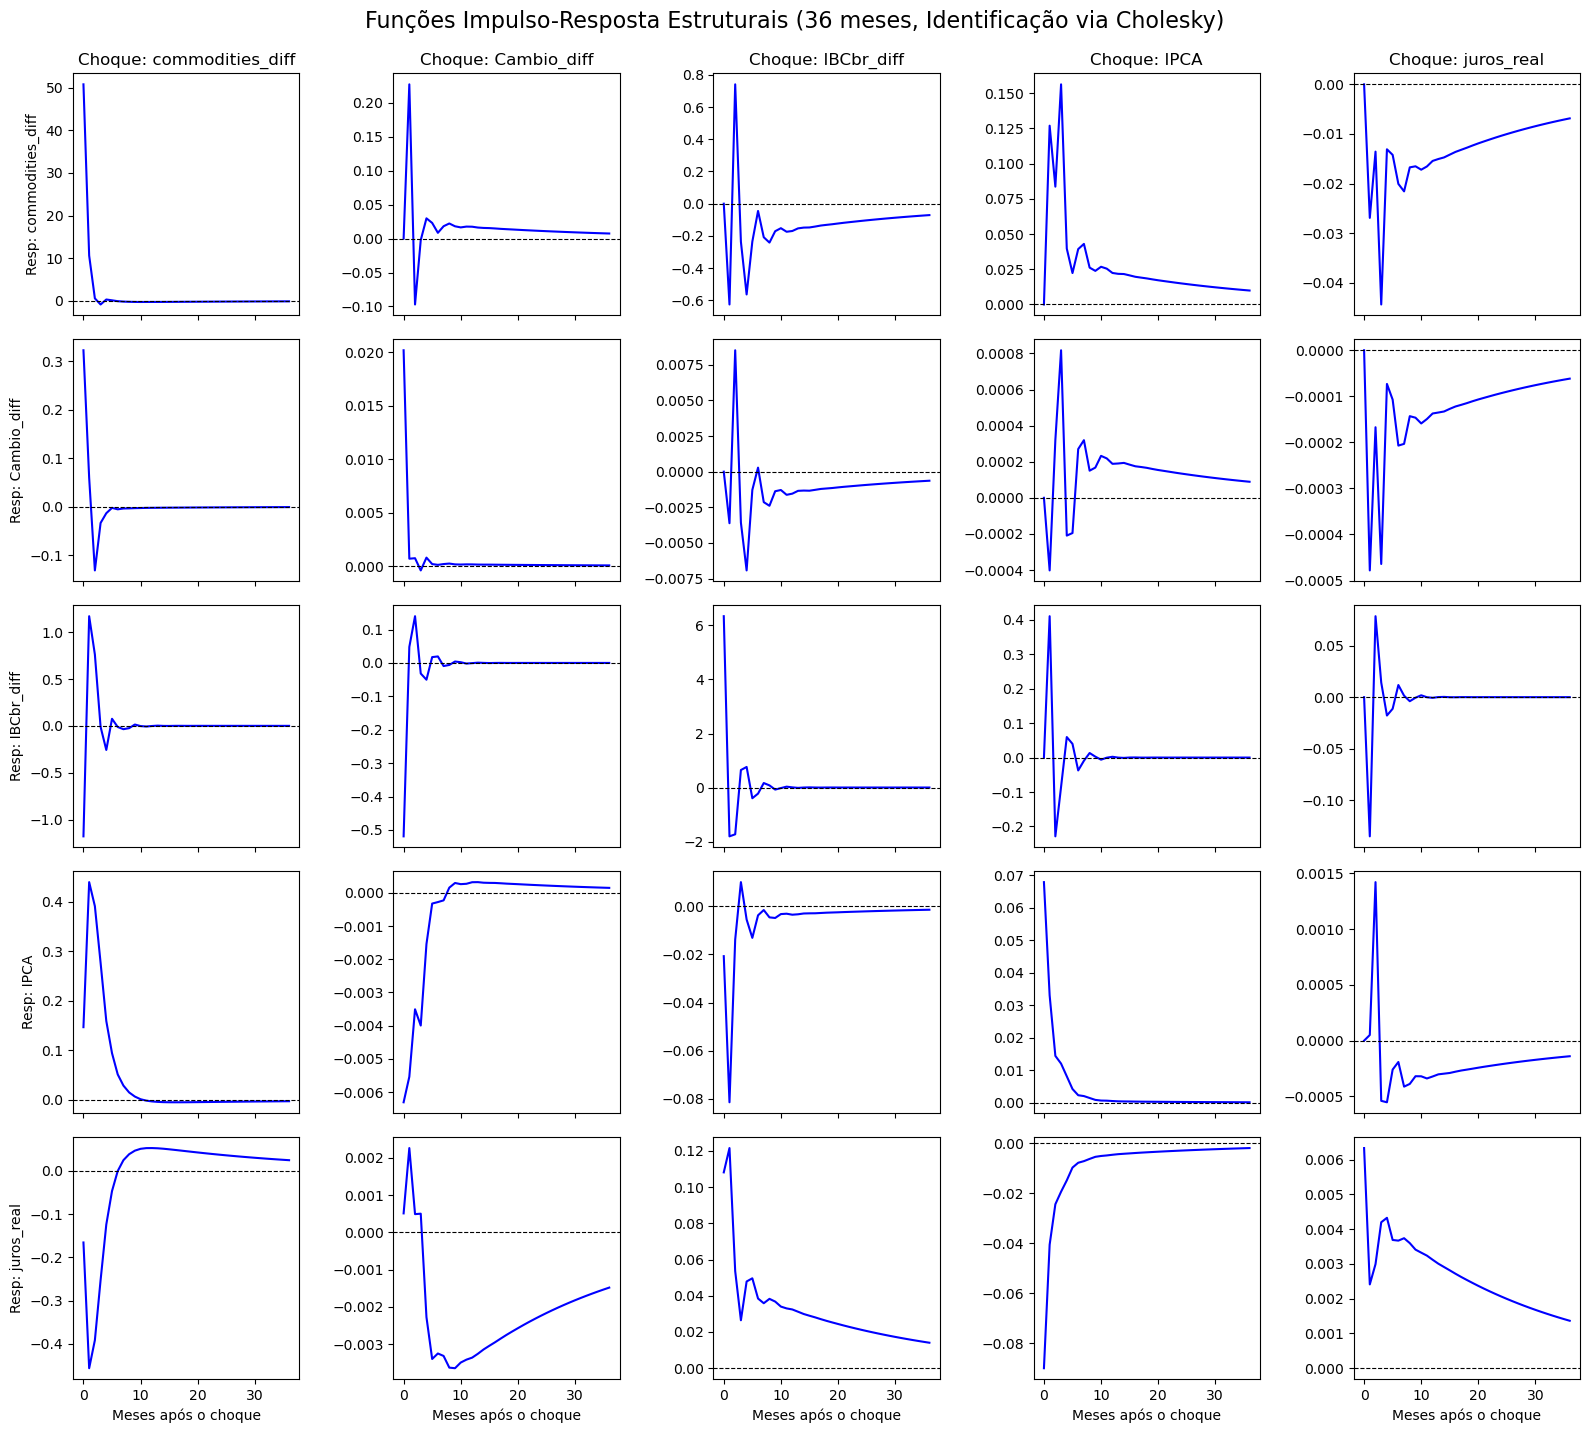

In [51]:
# 2. Estimar o VAR reduzido
model = VAR(df4)
lag_order = 2  
results = model.fit(lag_order)

# 3. Obter a matriz de covariância dos resíduos
u = results.resid
Sigma_u = np.cov(u.T)

# 4. Decomposição de Cholesky
P = cholesky(Sigma_u)

# Verificar a matriz P (matriz de impacto contemporâneo)
print("Matriz de impacto estrutural (Cholesky):\n", P)

# 5. Calcular IRFs estruturais com horizonte de 36 meses
h = 36
irfs_reduced = results.irf(h)
irfs_structural = np.array([irfs_reduced.orth_irfs[i] @ P for i in range(h + 1)])

# 6. Plotar IRFs estruturais
variables = df4.columns
fig, axes = plt.subplots(5, 5, figsize=(16, 14), sharex=True)

for i in range(5):  # resposta
    for j in range(5):  # choque
        axes[i, j].plot(range(h + 1), irfs_structural[:, i, j], color='blue')
        axes[i, j].axhline(0, color='black', linewidth=0.8, linestyle='--')
        if i == 0:
            axes[i, j].set_title(f'Choque: {variables[j]}')
        if j == 0:
            axes[i, j].set_ylabel(f'Resp: {variables[i]}')
        if i == 4:
            axes[i, j].set_xlabel('Meses após o choque')

plt.tight_layout()
plt.suptitle("Funções Impulso-Resposta Estruturais (36 meses, Identificação via Cholesky)", fontsize=16, y=1.02)
plt.show()

Matriz de impacto estrutural (Cholesky):
 [[ 7.05642671  0.          0.          0.          0.        ]
 [ 0.04391538  0.14065337  0.          0.          0.        ]
 [-0.12023373 -0.19324903  2.4942796   0.          0.        ]
 [ 0.01967089 -0.01909515 -0.00738854  0.25810684  0.        ]
 [-0.02147225  0.01511542  0.04045493 -0.26187183  0.07879123]]


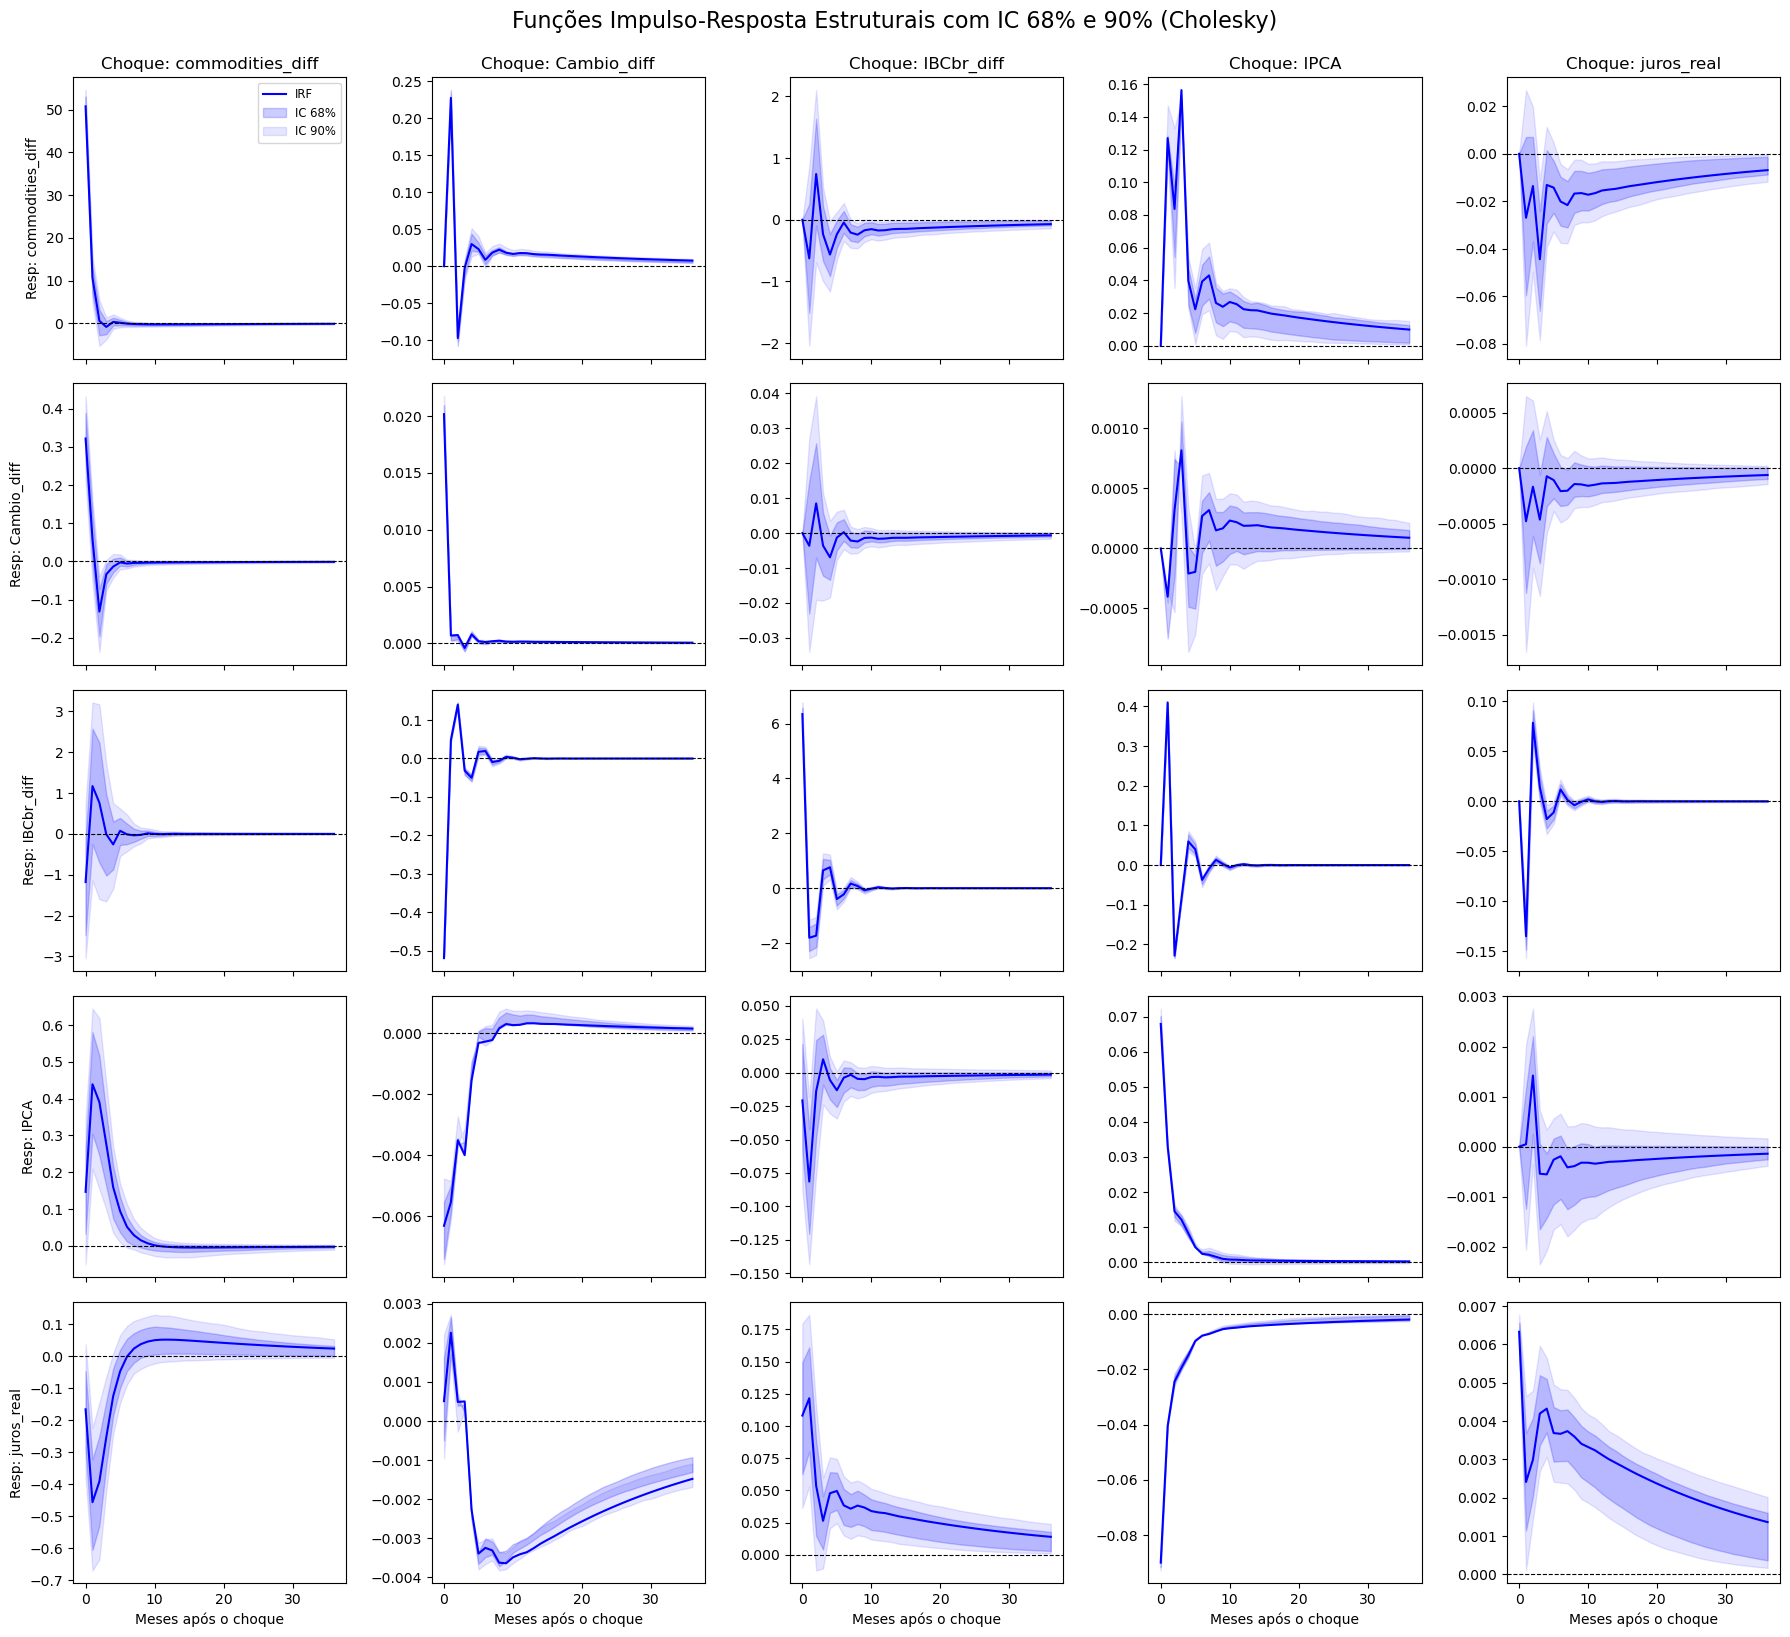

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from numpy.linalg import cholesky

# 1. Estimar o VAR reduzido
model = VAR(df4)
lag_order = 2  # exemplo
results = model.fit(lag_order)

# 2. Obter a matriz de covariância dos resíduos
u = results.resid
Sigma_u = np.cov(u.T)

# 3. Decomposição de Cholesky
P = cholesky(Sigma_u)
print("Matriz de impacto estrutural (Cholesky):\n", P)

# 4. Calcular IRFs com horizonte de 36 meses
h = 36
irfs = results.irf(h)

# IRFs ortogonais (reduzidas)
irf_reduced = irfs.orth_irfs

# 5. Intervalos de confiança via Monte Carlo
ci68_lower, ci68_upper = irfs.errband_mc(repl=1000, signif=0.32, orth=True)
ci90_lower, ci90_upper = irfs.errband_mc(repl=1000, signif=0.10, orth=True)

# 6. Transformar IRFs e ICs para versão estrutural
irf_structural = np.array([irf_reduced[i] @ P for i in range(h + 1)])
ci68_lower_struct = np.array([ci68_lower[i] @ P for i in range(h + 1)])
ci68_upper_struct = np.array([ci68_upper[i] @ P for i in range(h + 1)])
ci90_lower_struct = np.array([ci90_lower[i] @ P for i in range(h + 1)])
ci90_upper_struct = np.array([ci90_upper[i] @ P for i in range(h + 1)])

# 7. Plotar IRFs estruturais com ICs
variables = df4.columns
fig, axes = plt.subplots(5, 5, figsize=(18, 16), sharex=True)

for i in range(5):  # variável resposta
    for j in range(5):  # choque
        axes[i, j].plot(range(h + 1), irf_structural[:, i, j], color='blue', label='IRF')

        # IC 68%
        axes[i, j].fill_between(
            range(h + 1),
            ci68_lower_struct[:, i, j],
            ci68_upper_struct[:, i, j],
            color='blue',
            alpha=0.2,
            label='IC 68%' if i == 0 and j == 0 else ""
        )

        # IC 90%
        axes[i, j].fill_between(
            range(h + 1),
            ci90_lower_struct[:, i, j],
            ci90_upper_struct[:, i, j],
            color='blue',
            alpha=0.1,
            label='IC 90%' if i == 0 and j == 0 else ""
        )

        axes[i, j].axhline(0, color='black', linewidth=0.8, linestyle='--')
        if i == 0:
            axes[i, j].set_title(f'Choque: {variables[j]}')
        if j == 0:
            axes[i, j].set_ylabel(f'Resp: {variables[i]}')
        if i == 4:
            axes[i, j].set_xlabel('Meses após o choque')

# Legenda no primeiro subplot
axes[0, 0].legend(loc='upper right', fontsize='small')
plt.tight_layout()
plt.suptitle("Funções Impulso-Resposta Estruturais com IC 68% e 90% (Cholesky)", fontsize=16, y=1.02)
plt.show()

#### FEVD

Matriz de impacto estrutural (Cholesky):
 [[ 7.05642671  0.          0.          0.          0.        ]
 [ 0.04391538  0.14065337  0.          0.          0.        ]
 [-0.12023373 -0.19324903  2.4942796   0.          0.        ]
 [ 0.01967089 -0.01909515 -0.00738854  0.25810684  0.        ]
 [-0.02147225  0.01511542  0.04045493 -0.26187183  0.07879123]]


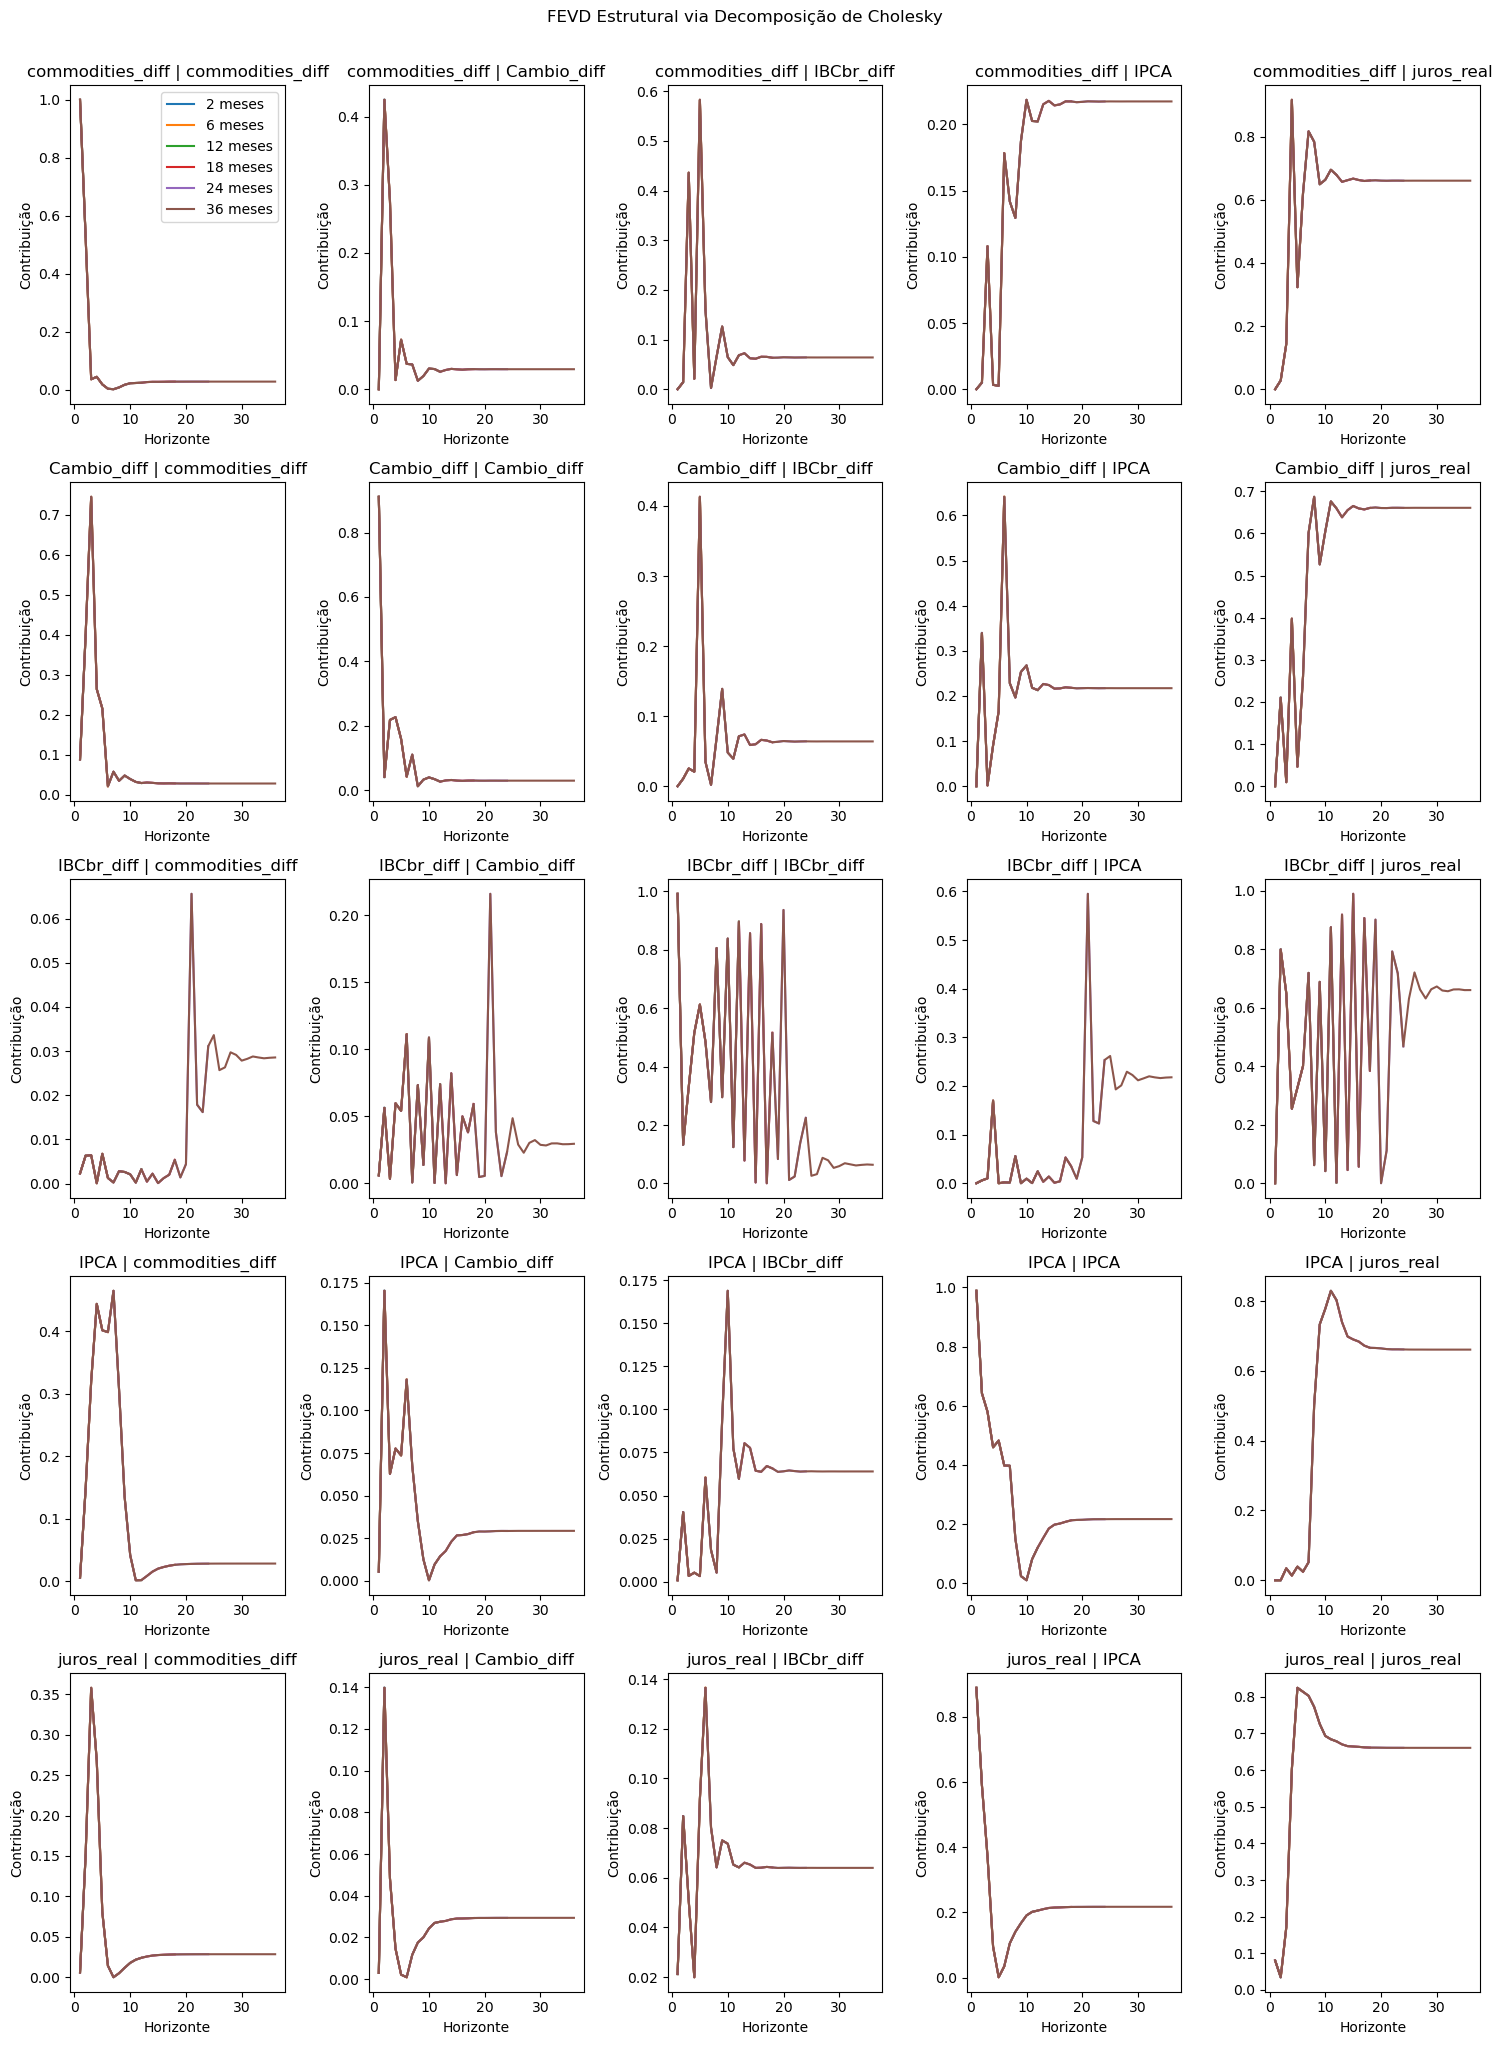

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from numpy.linalg import cholesky

# 1. Estimar o VAR reduzido
model = VAR(df4)
lag_order = 2  # exemplo
results = model.fit(lag_order)

# 2. Obter a matriz de covariância dos resíduos
u = results.resid
Sigma_u = np.cov(u.T)

# 3. Decomposição de Cholesky
P = cholesky(Sigma_u)  # Matriz de impacto estrutural
print("Matriz de impacto estrutural (Cholesky):\n", P)

# 4. Calcular FEVD para os horizontes desejados
horizons = [2, 6, 12, 18, 24, 36]
n_vars = len(df4.columns)
fevd_results = {}

for h in horizons:
    # Obter a representação MA (médias móveis)
    ma_rep = results.ma_rep(h)
    
    # Calcular a FEVD estrutural
    fevd = np.zeros((h, n_vars, n_vars))
    for i in range(h):
        theta = ma_rep[i] @ P
        fevd[i] = (theta ** 2) / np.sum(theta ** 2, axis=1, keepdims=True)
    
    fevd_results[h] = fevd

# 5. Plotar os resultados
variables = df4.columns
n_shocks = n_vars

plt.figure(figsize=(15, 20))
for response_idx, response_var in enumerate(variables):
    for shock_idx, shock_var in enumerate(variables):
        plt.subplot(n_vars, n_vars, response_idx * n_vars + shock_idx + 1)
        
        for h in horizons:
            # Pegar a contribuição acumulada até o horizonte h
            contribution = fevd_results[h][:, response_idx, shock_idx]
            plt.plot(range(1, h+1), contribution, label=f'{h} meses')
        
        plt.title(f'{response_var} | {shock_var}')
        plt.xlabel('Horizonte')
        plt.ylabel('Contribuição')
        if response_idx == 0 and shock_idx == 0:
            plt.legend()

plt.tight_layout()
plt.suptitle("FEVD Estrutural via Decomposição de Cholesky", y=1.02)
plt.show()

## QUESTÃO 2

Refaça a estimação do VAR impondo restrição de sinais. Você deve usar Inflação 
IPCA, Taxa de juros real (a que você construiu), índice de preço das commodities, IBC-Br, e tax 
de câmbio. Você pode usar ou Uhlig (2005), ou Mountford and Uhlig (2009) ou ainda Arias et al.
(2018) como referência. Basta escolher um método e não precisa explicá-
- Apresente em uma tabela as restrições impostas e indique o período de tempo que você utilizou para impor as restrições.
- Obtenha as IRFs e a FEVD, e discuta seus resultados.
- Algum resultado diferente em relação à identificação recursiva?ursiva?

Buscando choques compatíveis com as restrições de sinais...


100%|█████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:01<00:00, 515.23it/s]


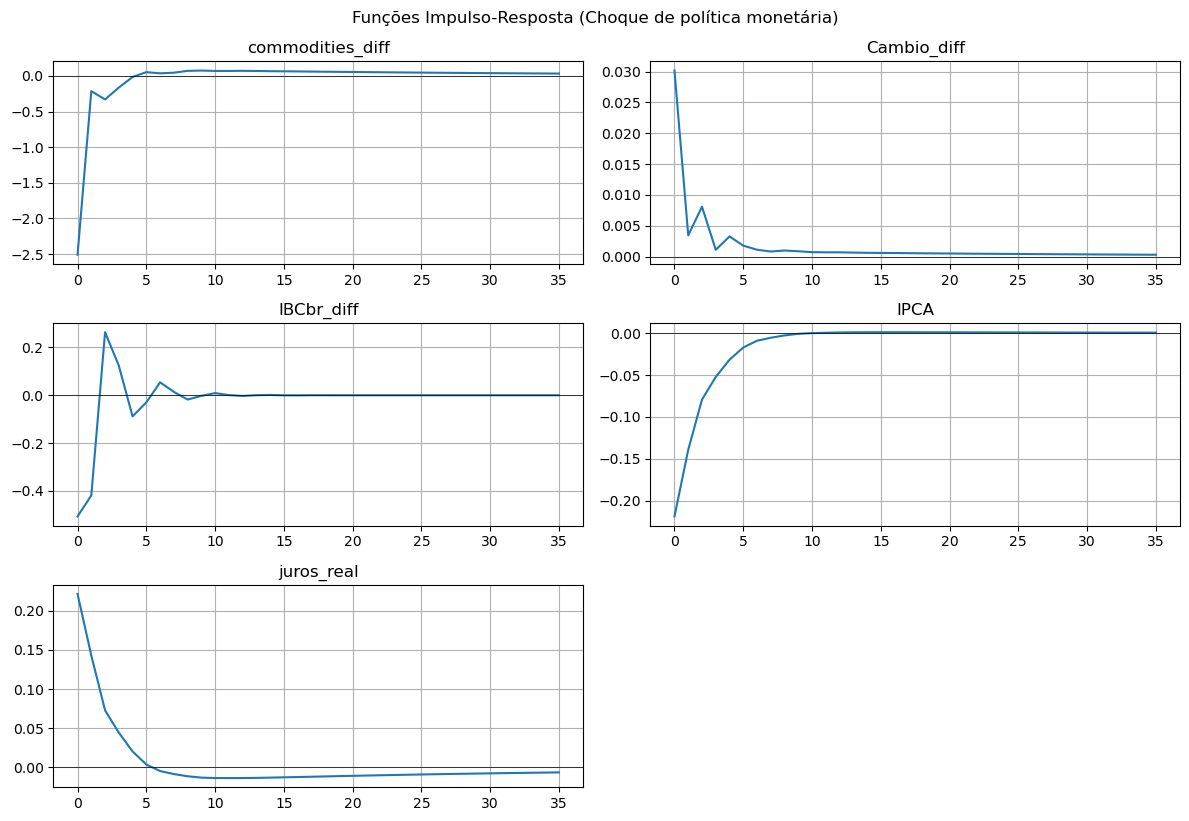

In [129]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from numpy.linalg import qr, cholesky
from tqdm import tqdm

# Estimação do VAR
model = VAR(df4)
p = 2
results = model.fit(p)

A = results.coefs
Sigma_u = results.sigma_u
irf_horizon = 36  # horizonte para IRFs

# Geração da matriz de impacto inicial
P = cholesky(Sigma_u)

# Função para gerar IRFs
def compute_irf(A, B, horizon):
    k = B.shape[0]
    p = A.shape[0]
    irfs = np.zeros((horizon, k))
    shock = B[:, 0]  # só estamos interessados no primeiro choque (política monetária)
    Y = np.zeros((p, k))
    Y[-1] = shock
    for h in range(horizon):
        response = Y[-1]
        irfs[h] = response
        Y_new = np.zeros_like(Y)
        for i in range(p):
            if h - i >= 0:
                Y_new[-1] += A[i] @ Y[-(i+1)]
        Y = np.roll(Y, -1, axis=0)
        Y[-1] = Y_new[-1]
    return irfs

# Restrições de sinais a serem impostas (Uhlig, choque de política monetária contracionista)
# Índices: [ipca, juros_real, commodities, ibcbr, cambio]
def satisfies_sign_restrictions(irf):
    # horizonte de 4 períodos (t=0 a t=3)
    return (
        np.all(irf[:4, 0] < 0) and  # inflação ↓
        np.all(irf[:4, 1] > 0) and  # juros ↑
        np.all(irf[:2, 2] < 0) and  # commodities ↓
        np.all(irf[:4, 3] < 0) and  # ibc-br ↓
        np.all(irf[:4, 4] > 0)      # câmbio ↑
    )

# Geração de Qs aleatórios e seleção via restrição de sinais
valid_irfs = []
n_draws = 1000
accepted = 0

print("Buscando choques compatíveis com as restrições de sinais...")
for _ in tqdm(range(n_draws)):
    Q, _ = qr(np.random.randn(len(variables), len(variables)))
    B = P @ Q
    irf = compute_irf(A, B, irf_horizon)
    if satisfies_sign_restrictions(irf):
        valid_irfs.append(irf)
        accepted += 1
    if accepted >= 100:
        break

valid_irfs = np.array(valid_irfs)
median_irf = np.median(valid_irfs, axis=0)

# Plot das IRFs
plt.figure(figsize=(12, 8))
for i, var in enumerate(variables):
    plt.subplot(3, 2, i + 1)
    plt.plot(median_irf[:, i], label=f'IRF - {var}')
    plt.axhline(0, color='black', linewidth=0.5)
    plt.title(var)
    plt.grid(True)
plt.tight_layout()
plt.suptitle("Funções Impulso-Resposta (Choque de política monetária)", y=1.02)
plt.show()


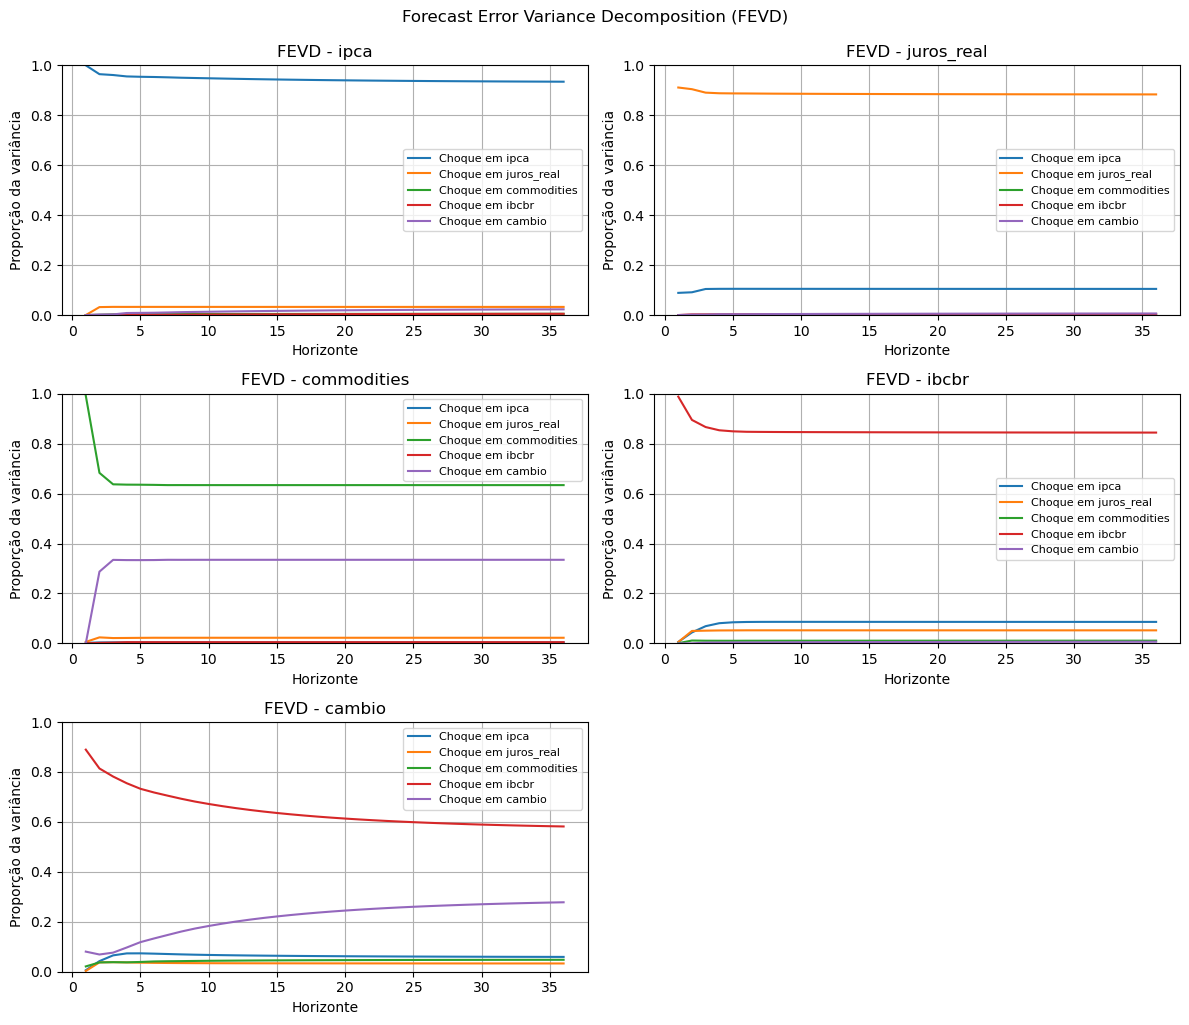

In [57]:
import numpy as np
import matplotlib.pyplot as plt

# Número de passos no horizonte
fevd_horizon = 36

# Obtenção da decomposição de Cholesky (pode ser substituída por outra matriz de impacto, se desejar)
P = cholesky(results.sigma_u)

# Função para computar a FEVD
def compute_fevd(results, P, horizon):
    irf = results.irf(horizon)
    orth_irfs = irf.orth_irfs  # IRFs ortogonalizadas
    k = orth_irfs.shape[1]

    fevd = np.zeros((horizon, k, k))  # [horizonte, variável, choque]

    for h in range(horizon):
        num = np.cumsum(orth_irfs[:h+1] ** 2, axis=0)  # soma acumulada dos quadrados das IRFs
        denom = num.sum(axis=2, keepdims=True)
        fevd[h] = num[-1] / denom[-1]  # proporção atribuída a cada choque

    return fevd  # [h, var, shock]

fevd_result = compute_fevd(results, P, fevd_horizon)

# Plotar a FEVD para cada variável (colunas: variáveis, linhas: choques)
variables = ['ipca', 'juros_real', 'commodities', 'ibcbr', 'cambio']
plt.figure(figsize=(12, 10))
for i, var in enumerate(variables):
    plt.subplot(3, 2, i + 1)
    for j in range(len(variables)):
        plt.plot(np.arange(1, fevd_horizon+1), fevd_result[:, i, j], label=f'Choque em {variables[j]}')
    plt.title(f'FEVD - {var}')
    plt.xlabel('Horizonte')
    plt.ylabel('Proporção da variância')
    plt.ylim(0, 1)
    plt.grid(True)
    plt.legend(fontsize=8)

plt.tight_layout()
plt.suptitle("Forecast Error Variance Decomposition (FEVD)", y=1.02)
plt.show()


## QUESTÃO 3

In [88]:
livres = bcb.sgs.get({'livres': 11428}, start='2003-01-01'),        # Índice nacional de preços ao consumidor - Amplo (IPCA) - Itens livres (variação % mensal)
adm = bcb.sgs.get({'adm': 4449}, start='2003-01-01'),               # Índice Nacional de Preços ao Consumidor - Amplo (IPCA) - Administrados (variação % mensal)
cambio3 = bcb.sgs.get({'cambio3': 3696}, start='2003-01-01'),         # Taxa de câmbio - Livre - Dólar americano (venda) - Fim de período - mensal (nível)
selic3 = bcb.sgs.get({'Selic3': 4390}, start='2003-01-01'),           # Taxa de juros - Selic acumulada no mês - (variação % mensal)
ibc3 = bcb.sgs.get({'IBCbr3': 24363}, start='2003-01-01'),            # IBC-Br mensal (índice)
ipca3 = bcb.sgs.get({'IPCA3': 433}, start='2003-01-01'),              # Variação percentual mensal do IPCA (variação % mensal)

print(adm)

(             adm
Date            
2003-01-01  3.83
2003-02-01  2.71
2003-03-01  1.08
2003-04-01  1.21
2003-05-01  0.81
...          ...
2024-11-01 -0.87
2024-12-01 -0.17
2025-01-01 -1.52
2025-02-01  3.16
2025-03-01  0.18

[267 rows x 1 columns],)


In [90]:
ibc3 = ibc3[0]                     # pegando só a coluna de dados
selic3 = selic3[0]
cambio3 = cambio3[0]
livres = livres[0]
adm = adm[0]
ipca3 = ipca3[0]

# Transformar em DataFrames
ibc3 = pd.DataFrame(ibc3)
ipca3 = pd.DataFrame(ipca3)
selic3 = pd.DataFrame(selic3)
cambio3 = pd.DataFrame(cambio3)
livres = pd.DataFrame(livres)
adm = pd.DataFrame(adm)

# Ajustar índices para período mensal (caso o índice seja datetime)
ibc3.index = pd.to_datetime(ibc3.index).to_period('M')
ipca3.index = pd.to_datetime(ipca3.index).to_period('M')
selic3.index = pd.to_datetime(selic3.index).to_period('M')
cambio3.index = pd.to_datetime(cambio3.index).to_period('M')
livres.index = pd.to_datetime(livres.index).to_period('M')
adm.index = pd.to_datetime(adm.index).to_period('M')

In [92]:
# Unir os três DataFrames pelo índice (join com interseção de datas)
df5 = pd.concat([ibc3, adm, livres, ipca3, selic3, cambio3], axis=1).dropna()

# Visualizar o resultado
print(df5.head())

           IBCbr3   adm  livres  IPCA3  Selic3  cambio3
Date                                                   
2003-01  67.44572  3.83    1.64   2.25    1.97   3.5258
2003-02  69.20861  2.71    1.12   1.57    1.83   3.5632
2003-03  72.53661  1.08    1.29   1.23    1.78   3.3531
2003-04  71.67673  1.21    0.87   0.97    1.87   2.8898
2003-05  70.35122  0.81    0.53   0.61    1.97   2.9656


In [96]:
# criando uma medida de juros real com o IPCA como deflator

df5['juros_real3'] = df5['Selic3'] - df5['IPCA3']

print(df5[['Selic3', 'IPCA3', 'juros_real3']].head())

         Selic3  IPCA3  juros_real3
Date                               
2003-01    1.97   2.25        -0.28
2003-02    1.83   1.57         0.26
2003-03    1.78   1.23         0.55
2003-04    1.87   0.97         0.90
2003-05    1.97   0.61         1.36


In [100]:
df6 = df5[['IBCbr3', 'livres', 'adm', 'IPCA3', 'juros_real3', 'cambio3']]

print(df6)

            IBCbr3  livres   adm  IPCA3  juros_real3  cambio3
Date                                                         
2003-01   67.44572    1.64  3.83   2.25        -0.28   3.5258
2003-02   69.20861    1.12  2.71   1.57         0.26   3.5632
2003-03   72.53661    1.29  1.08   1.23         0.55   3.3531
2003-04   71.67673    0.87  1.21   0.97         0.90   2.8898
2003-05   70.35122    0.53  0.81   0.61         1.36   2.9656
...            ...     ...   ...    ...          ...      ...
2024-10  109.49845    0.51  0.71   0.56         0.37   5.7779
2024-11  105.76017    0.84 -0.87   0.39         0.40   6.0535
2024-12  104.44111    0.76 -0.17   0.52         0.41   6.1923
2025-01  103.05176    0.75 -1.52   0.16         0.85   5.8301
2025-02  106.61259    0.68  3.16   1.31        -0.32   5.8488

[266 rows x 6 columns]
